## Project Summary

Predicting missing Implied Volatility (IV) values in the NIFTY 50 
options chain dataset — January 2026 expiry cycle (07 Jan – 27 Jan 2026).

**Dataset:** 975 timestamps × 28 option columns × 5460 missing values  
**Evaluation Metric:** Mean Squared Error (MSE) — lower is better  
**Best Kaggle Score:** 0.0002694642  

---

## Methodology Overview

| Step | Approach | Kaggle MSE |
|------|----------|------------|
| Baseline | Linear interpolation | 0.0020717237 |
| Improvement 1 | Neighbour averaging | 0.0014434083 |
| Improvement 2 | Combined time + strike | 0.0012539798 |
| Improvement 3 | Extended combined (2 steps) | 0.0005527288 |
| Best Model | Rank-2 Iterative PCA | 0.0002694642 |

---

## Key Financial Insight

The IV surface behaves as a **2-factor model**:
- **Factor 1** (97.4% variance) — overall volatility level
- **Factor 2** (99.3% cumulative) — volatility skew steepness

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from sklearn.metrics import mean_squared_error
import re
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully !!")

Libraries loaded successfully !!


---
## Step 1 — Load and Explore Dataset

Load the NIFTY options IV dataset and understand its structure.
Key observations:
- 975 rows = 5-minute snapshots across 3 weeks
- 28 IV columns = 14 CE (Call) + 14 PE (Put) options
- 5460 missing values = ~20% of all cells
- Missing values are randomly scattered — not clustered

In [14]:
# Load the dataset from CSV file
df = pd.read_csv("dataset.csv")

# Convert datetime column from text to proper datetime format
# This is needed for time-based interpolation later
df['datetime'] = pd.to_datetime(df['datetime'], format='%d-%m-%Y %H:%M')

# Separate CE (Call) and PE (Put) option columns
ce_columns = [c for c in df.columns if c.endswith('CE')]
pe_columns = [c for c in df.columns if c.endswith('PE')]
iv_columns = ce_columns + pe_columns

# Basic exploration
print("Shape:", df.shape)
print("Total missing values:", df[iv_columns].isnull().sum().sum())
print("CE columns:", len(ce_columns))
print("PE columns:", len(pe_columns))

Shape: (975, 30)
Total missing values: 5460
CE columns: 14
PE columns: 14


---
## Step 2 — Decode Column Names

Each column name encodes the strike price and option type.
Example: NIFTY27JAN2625200CE → Strike 25200, Call option

- CE strikes: 25200 to 26500 (above current Nifty ~25600)
- PE strikes: 23800 to 25100 (below current Nifty ~25600)
- Moneyness = Strike / Spot Price (ATM = 1.0)

In [15]:
# Extract strike price from column name using regex
# Example: 'NIFTY27JAN2625200CE' -> 25200
# \d{5} means exactly 5 digits, (CE|PE)$ means ends with CE or PE
def strike_price(column_name):
    match = re.search(r'(\d{5})(CE|PE)$', column_name)
    return int(match.group(1))

# Extract option type from column name
# [-2:] means last 2 characters
# Example: 'NIFTY27JAN2625200CE' -> 'CE'
def get_type(column_name):
    return column_name[-2:]

# Test both functions
print(strike_price('NIFTY27JAN2625200CE'))
print(strike_price('NIFTY27JAN2624800PE'))
print(get_type('NIFTY27JAN2625200CE'))
print(get_type('NIFTY27JAN2624800PE'))

25200
24800
CE
PE


---
## Step 3 — Visualize the IV Surface

### Volatility Smile and Skew
- CE options show a **volatility smile** — IV dips near ATM and rises at extremes
- PE options show a **volatility skew** — IV increases as strike decreases
- This asymmetry exists because investors buy puts as crash insurance
- Higher put demand → higher put IV → downward sloping PE curve

Understanding this shape is crucial — our model must respect it.

Plotting smile at: 2026-01-12 11:45:00
NIFTY spot price: 25477


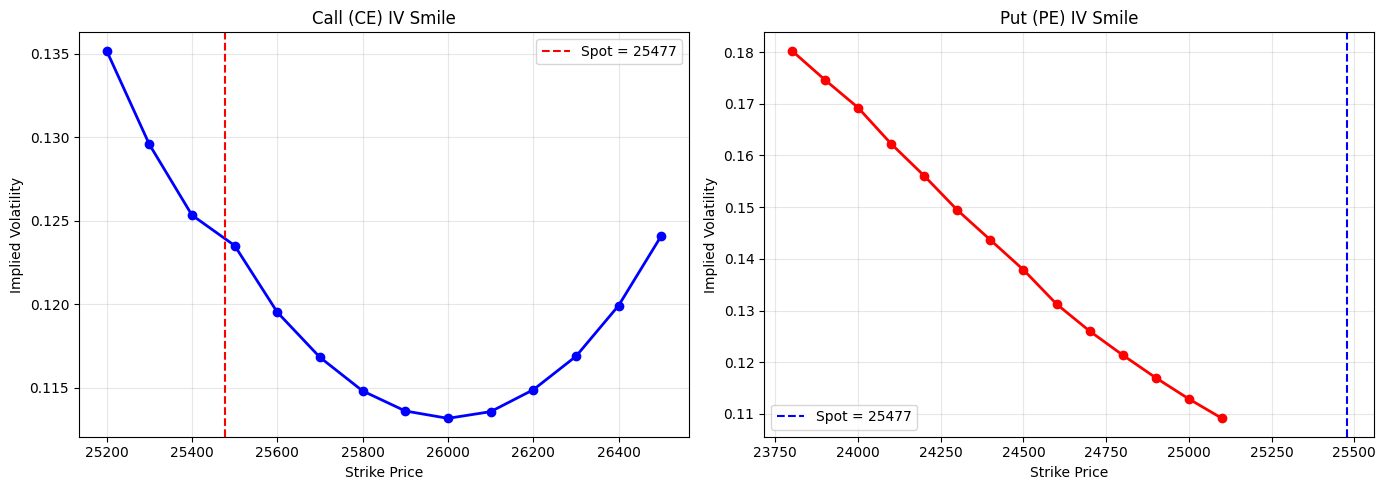

In [16]:
best_row_idx = df[iv_columns].notna().sum(axis = 1).idxmax()
sample_row = df.loc[best_row_idx]
sample_time = sample_row['datetime']
spot = sample_row['underlying_price']

print(f"Plotting smile at: {sample_time}")
print(f"NIFTY spot price: {spot:.0f}")

ce_data = [(strike_price(c), sample_row[c]) for c in ce_columns if pd.notna(sample_row[c])]
pe_data = [(strike_price(c), sample_row[c]) for c in pe_columns if pd.notna(sample_row[c])]

ce_data.sort()
pe_data.sort()

fig ,axes = plt.subplots(1, 2, figsize=(14, 5))
x_ce, y_ce = zip(*ce_data)
axes[0].plot(x_ce, y_ce, 'bo-', linewidth = 2, markersize = 6)
axes[0].axvline(x=spot, color='red', linestyle='--', label=f'Spot = {spot:.0f}')
axes[0].set_title('Call (CE) IV Smile')
axes[0].set_xlabel('Strike Price')
axes[0].set_ylabel('Implied Volatility')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

x_pe, y_pe = zip(*pe_data)
axes[1].plot(x_pe, y_pe, 'ro-', linewidth=2, markersize=6)
axes[1].axvline(x=spot, color='blue', linestyle='--', label=f'Spot = {spot:.0f}')
axes[1].set_title('Put (PE) IV Smile')
axes[1].set_xlabel('Strike Price')
axes[1].set_ylabel('Implied Volatility')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
### IV Over Time
- IV evolves smoothly across 5-minute intervals
- No sudden jumps — confirms interpolation is valid
- Higher strikes (CE) consistently have lower IV
- Lower strikes (PE) consistently have higher IV
- Mean reversion visible — IV spikes and returns to normal

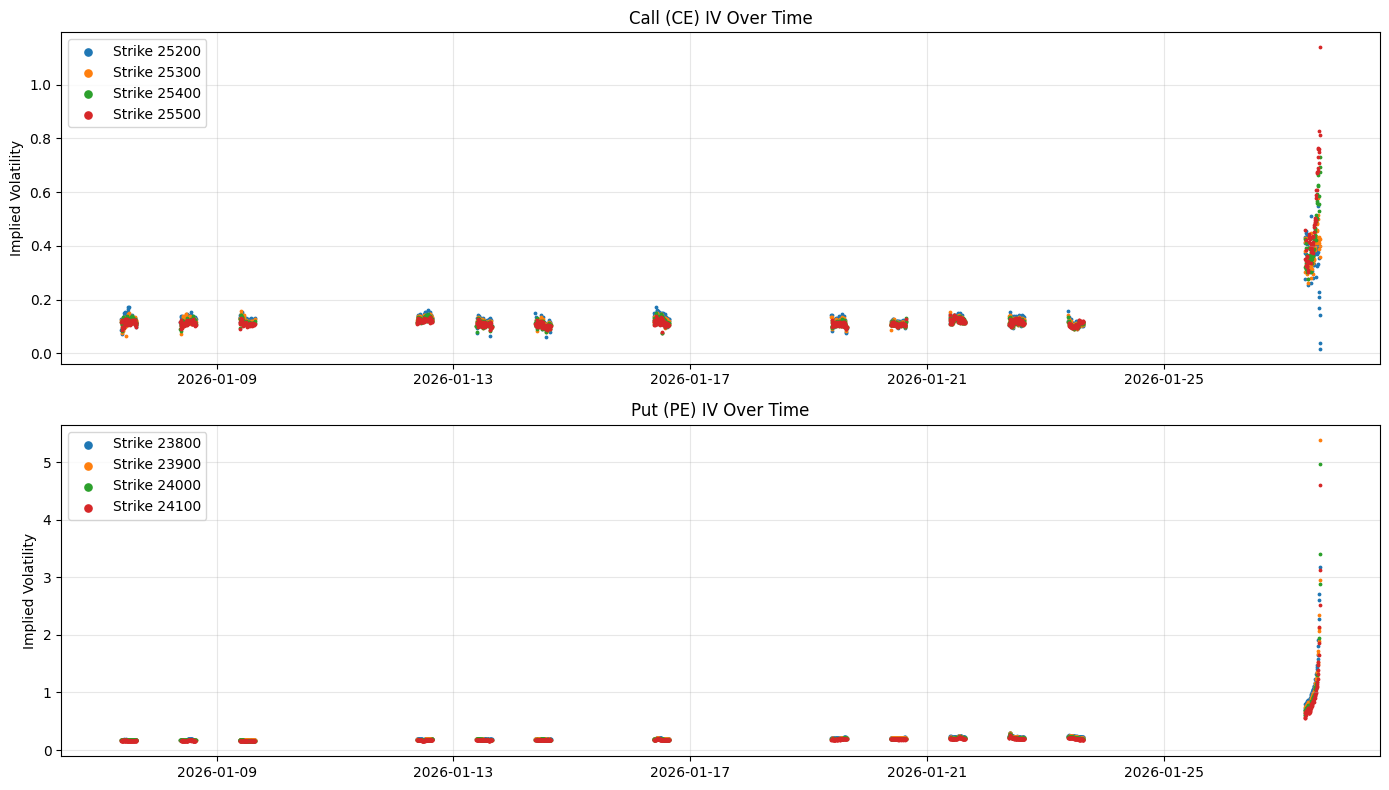

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for column in ce_columns[:4]:
    strike = strike_price(column)
    series = df.set_index('datetime')[column].dropna()
    axes[0].scatter(series.index, series.values, s=3, label=f'Strike {strike}')

axes[0].set_title('Call (CE) IV Over Time')
axes[0].set_ylabel('Implied Volatility')
axes[0].legend(markerscale=3)
axes[0].grid(True, alpha=0.3)

for column in pe_columns[:4]:
    strike = strike_price(column)
    series = df.set_index('datetime')[column].dropna()
    axes[1].scatter(series.index, series.values, s=3, label=f'Strike {strike}')

axes[1].set_title('Put (PE) IV Over Time')
axes[1].set_ylabel('Implied Volatility')
axes[1].legend(markerscale=3)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
### Missing Value Pattern
- Missing values are randomly scattered across the entire matrix
- No large blocks of consecutive missing values
- Every missing cell has known neighbours nearby
- This confirms interpolation and surface fitting approaches are valid

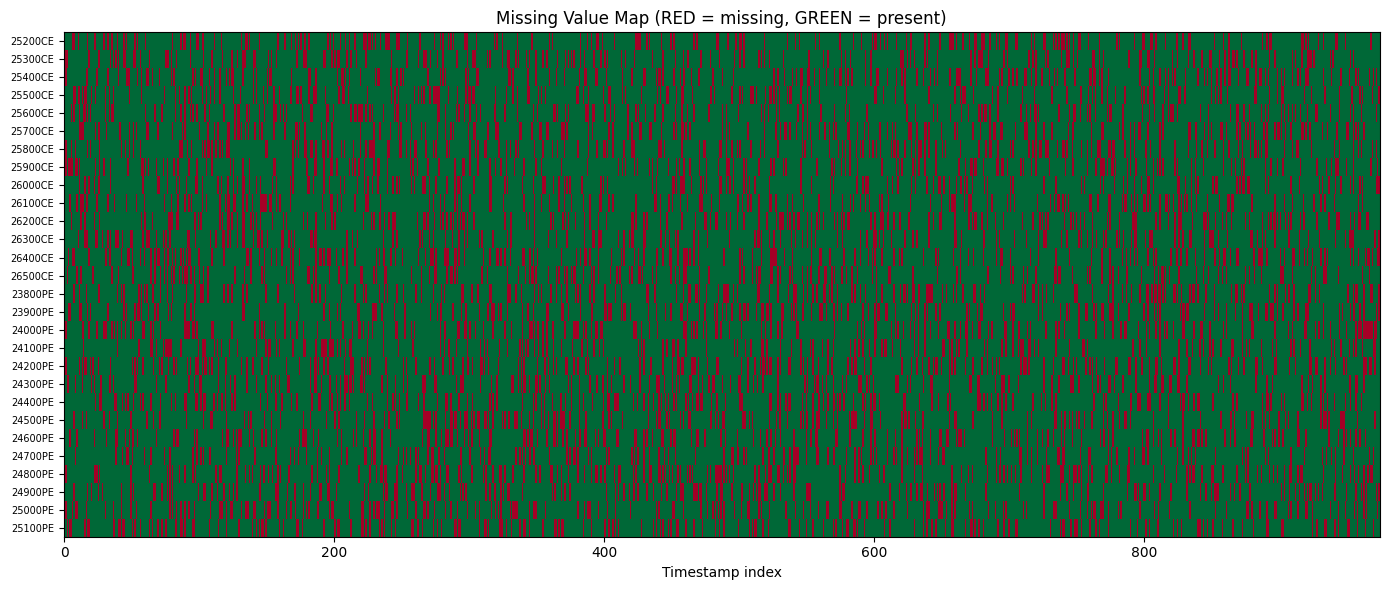

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))

missing_matrix = df[iv_columns].isnull().astype(int)

ax.imshow(missing_matrix.T, aspect='auto', cmap='RdYlGn_r',
          vmin=0, vmax=1, interpolation='none')

ax.set_yticks(range(len(iv_columns)))
ax.set_yticklabels([f'{strike_price(c)}{get_type(c)}' for c in iv_columns], fontsize=7)
ax.set_xlabel('Timestamp index')
ax.set_title('Missing Value Map (RED = missing, GREEN = present)')

plt.tight_layout()
plt.show()

---
## Step 4 — Validation Strategy

To measure model accuracy without seeing Kaggle hidden values:
1. Take 20% of KNOWN values and artificially hide them
2. Run our model to predict those hidden values
3. Compare predictions to true values using MSE
4. Lower validation MSE = better model

**Important:** We use `np.random.seed(42)` to ensure 
reproducibility — same values are hidden every run.

**No lookahead bias:** Features only use past timestamps 
and same-timestamp cross-sectional data.

In [19]:
# Set random seed for reproducibility
# Same values will be hidden every time this cell runs
np.random.seed(42)

# Step 1: Find all known (non-missing) values
known_mask = df[iv_columns].notna()

# Step 2: Create empty validation mask — all False initially
val_mask = known_mask.copy() * False

# Step 3: For each column, randomly hide 20% of known values
for col in iv_columns:
    known_indices = df.index[known_mask[col]].tolist()
    n_hide = max(1, int(len(known_indices) * 0.2))
    hide_indices = np.random.choice(known_indices, size=n_hide, replace=False)
    val_mask.loc[hide_indices, col] = True

# Step 4: Create validation dataset with hidden values
df_val = df.copy()
df_val[iv_columns] = df_val[iv_columns].where(~val_mask)

# Step 5: Store true values for MSE calculation later
true_vals = df[iv_columns][val_mask].values.flatten()
true_vals = true_vals[~np.isnan(true_vals)]

print(f"Validation set created!")
print(f"Hidden values: {val_mask.sum().sum()}")
print(f"True values stored: {len(true_vals)}")

Validation set created!
Hidden values: 4358
True values stored: 4358


---
## Step 5 — Model Building Journey

### Model 1: Neighbour Averaging
**Idea:** Each missing cell is estimated as the average of its 
immediate neighbours:
- Previous timestamp (same strike, no lookahead)
- Left neighbour strike (same timestamp)
- Right neighbour strike (same timestamp)

**Financial intuition:** IV varies smoothly across both time 
and strikes. Immediate neighbours are the most reliable 
predictors of a missing value.

**Result:** Kaggle MSE = 0.0014434083

In [20]:
# Model 1: Neighbour Averaging
# For each missing cell, predict using average of available neighbours
# Neighbours used: previous timestamp, left strike, right strike
# NO lookahead bias — we never use future timestamps

df_neighbour = df.copy()

for col in iv_columns:
    # Get position of this column in the list
    col_idx = iv_columns.index(col)
    
    # Loop through only the missing rows for this column
    for idx in df.index[df[col].isna()]:
        neighbours = []
        
        # Previous timestamp — same strike, one step back in time
        # This is allowed — it's in the past
        if idx > 0 and pd.notna(df.loc[idx-1, col]):
            neighbours.append(df.loc[idx-1, col])
        
        # Left neighbour — lower strike, same timestamp
        # Cross-sectional data is always allowed
        if col_idx > 0 and pd.notna(df.loc[idx, iv_columns[col_idx-1]]):
            neighbours.append(df.loc[idx, iv_columns[col_idx-1]])
        
        # Right neighbour — higher strike, same timestamp
        if col_idx < len(iv_columns)-1 and pd.notna(df.loc[idx, iv_columns[col_idx+1]]):
            neighbours.append(df.loc[idx, iv_columns[col_idx+1]])
        
        # Predict as simple average of available neighbours
        if len(neighbours) > 0:
            df_neighbour.loc[idx, col] = np.mean(neighbours)

# Fill any remaining missing with time interpolation
df_neighbour[iv_columns] = (
    df_neighbour
    .set_index('datetime')[iv_columns]
    .interpolate(method='time')
    .reset_index(drop=True)
)

# Safety net — fill anything still missing with column median
for col in iv_columns:
    df_neighbour[col] = df_neighbour[col].fillna(df_neighbour[col].median())

print(f"Missing remaining: {df_neighbour[iv_columns].isnull().sum().sum()}")
print("Neighbour model complete!")

Missing remaining: 0
Neighbour model complete!


In [21]:
# Validate neighbour model using same hidden values
df_val_neighbour = df_val.copy()

for col in iv_columns:
    col_idx = iv_columns.index(col)
    
    for idx in df_val.index[df_val[col].isna()]:
        neighbours = []
        
        # Previous timestamp — no lookahead!
        if idx > 0 and pd.notna(df_val.loc[idx-1, col]):
            neighbours.append(df_val.loc[idx-1, col])
        
        # Left neighbour strike — same timestamp
        if col_idx > 0 and pd.notna(df_val.loc[idx, iv_columns[col_idx-1]]):
            neighbours.append(df_val.loc[idx, iv_columns[col_idx-1]])
        
        # Right neighbour strike — same timestamp
        if col_idx < len(iv_columns)-1 and pd.notna(df_val.loc[idx, iv_columns[col_idx+1]]):
            neighbours.append(df_val.loc[idx, iv_columns[col_idx+1]])
        
        if len(neighbours) > 0:
            df_val_neighbour.loc[idx, col] = np.mean(neighbours)

# Fill remaining
df_val_neighbour[iv_columns] = (
    df_val_neighbour
    .set_index('datetime')[iv_columns]
    .interpolate(method='time')
    .reset_index(drop=True)
)

for col in iv_columns:
    df_val_neighbour[col] = df_val_neighbour[col].fillna(df_val_neighbour[col].median())

# Calculate MSE
pred_neighbour = df_val_neighbour[iv_columns][val_mask].values.flatten()
pred_neighbour = pred_neighbour[~np.isnan(pred_neighbour)]

min_len = min(len(true_vals), len(pred_neighbour))
pred_neighbour = pred_neighbour[:min_len]
true_trimmed = true_vals[:min_len]

mse_neighbour = mean_squared_error(true_trimmed, pred_neighbour)

print(f"Neighbour model MSE: {mse_neighbour:.8f}")

Neighbour model MSE: 0.00045518


---
### Model 2: Combined Time + Strike Model
**Idea:** Two step approach:
1. First apply time interpolation using pandas — this uses 
   BOTH previous AND next known timestamp for each strike
2. Then blend with left and right strike neighbours

**Why better than pure neighbour averaging:**
- Time interpolation captures the full temporal structure
- Strike neighbours capture the smile shape
- Combining both dimensions simultaneously gives more information

**Result:** Kaggle MSE = 0.0012539798

In [22]:
df_combined = df.copy()

# Step 1: First do time interpolation (uses previous AND next)
df_combined[iv_columns] = (
    df_combined
    .set_index('datetime')[iv_columns]
    .interpolate(method='time')
    .reset_index(drop=True)
)

# Step 2: For originally missing values, blend with strike neighbours
for col in iv_columns:
    col_idx = iv_columns.index(col)
    
    for idx in df.index[df[col].isna()]:
        neighbours = []
        
        # Time interpolated value (already filled above)
        time_pred = df_combined.loc[idx, col]
        if pd.notna(time_pred):
            neighbours.append(time_pred)
        
        # Left neighbour — original known value only
        if col_idx > 0:
            left_val = df.loc[idx, iv_columns[col_idx-1]]
            if pd.notna(left_val):
                neighbours.append(left_val)
        
        # Right neighbour — original known value only
        if col_idx < len(iv_columns)-1:
            right_val = df.loc[idx, iv_columns[col_idx+1]]
            if pd.notna(right_val):
                neighbours.append(right_val)
        
        if len(neighbours) > 0:
            df_combined.loc[idx, col] = np.mean(neighbours)

# Safety net
for col in iv_columns:
    df_combined[col] = df_combined[col].fillna(df_combined[col].median())

print(f"Missing remaining: {df_combined[iv_columns].isnull().sum().sum()}")
print("Combined model complete!")

Missing remaining: 0
Combined model complete!


In [23]:
# Validate combined model
df_val_combined = df_val.copy()

# Step 1: Time interpolation
df_val_combined[iv_columns] = (
    df_val_combined
    .set_index('datetime')[iv_columns]
    .interpolate(method='time')
    .reset_index(drop=True)
)

# Step 2: Blend with strike neighbours
for col in iv_columns:
    col_idx = iv_columns.index(col)
    
    for idx in df_val.index[df_val[col].isna()]:
        neighbours = []
        
        time_pred = df_val_combined.loc[idx, col]
        if pd.notna(time_pred):
            neighbours.append(time_pred)
        
        if col_idx > 0:
            left_val = df_val.loc[idx, iv_columns[col_idx-1]]
            if pd.notna(left_val):
                neighbours.append(left_val)
        
        if col_idx < len(iv_columns)-1:
            right_val = df_val.loc[idx, iv_columns[col_idx+1]]
            if pd.notna(right_val):
                neighbours.append(right_val)
        
        if len(neighbours) > 0:
            df_val_combined.loc[idx, col] = np.mean(neighbours)

for col in iv_columns:
    df_val_combined[col] = df_val_combined[col].fillna(
        df_val_combined[col].median()
    )

# Calculate MSE
pred_combined = df_val_combined[iv_columns][val_mask].values.flatten()
pred_combined = pred_combined[~np.isnan(pred_combined)]

min_len = min(len(true_vals), len(pred_combined))
pred_combined = pred_combined[:min_len]
true_trimmed = true_vals[:min_len]

mse_combined = mean_squared_error(true_trimmed, pred_combined)

print(f"Combined model MSE:  {mse_combined:.8f}")
print(f"Neighbour model MSE: 0.00045518")
print()
if mse_combined < 0.00045518:
    print("Combined model is better!")
else:
    print("Neighbour model is still better.")

Combined model MSE:  0.00027032
Neighbour model MSE: 0.00045518

Combined model is better!


---
### Model 3: Extended Combined Model (2 Step Neighbours)
**Idea:** Same as Model 2 but extend strike neighbours to 2 steps:
- Time interpolation (previous + next timestamp)
- 1 step left strike
- 1 step right strike
- 2 steps left strike
- 2 steps right strike

**Why better:** More strike context captures the smile curve 
shape more accurately. 2 steps is the sweet spot — 3 steps 
adds noise from strikes too far away.

**Result:** Kaggle MSE = 0.0005527288 — 73% improvement over baseline

In [24]:
df_combined_extended = df.copy()

# Step 1: Time interpolation
df_combined_extended[iv_columns] = (
    df_combined_extended
    .set_index('datetime')[iv_columns]
    .interpolate(method='time')
    .reset_index(drop=True)
)

# Step 2: Blend with extended strike neighbours
for col in iv_columns:
    col_idx = iv_columns.index(col)
    
    for idx in df.index[df[col].isna()]:
        neighbours = []
        
        # Time prediction
        time_pred = df_combined_extended.loc[idx, col]
        if pd.notna(time_pred):
            neighbours.append(time_pred)
        
        # 1 step left
        if col_idx > 0:
            val = df.loc[idx, iv_columns[col_idx-1]]
            if pd.notna(val):
                neighbours.append(val)
        
        # 1 step right
        if col_idx < len(iv_columns)-1:
            val = df.loc[idx, iv_columns[col_idx+1]]
            if pd.notna(val):
                neighbours.append(val)
        
        # 2 steps left
        if col_idx > 1:
            val = df.loc[idx, iv_columns[col_idx-2]]
            if pd.notna(val):
                neighbours.append(val)
        
        # 2 steps right
        if col_idx < len(iv_columns)-2:
            val = df.loc[idx, iv_columns[col_idx+2]]
            if pd.notna(val):
                neighbours.append(val)
        
        if len(neighbours) > 0:
            df_combined_extended.loc[idx, col] = np.mean(neighbours)

# Safety net
for col in iv_columns:
    df_combined_extended[col] = df_combined_extended[col].fillna(
        df_combined_extended[col].median()
    )

print(f"Missing remaining: {df_combined_extended[iv_columns].isnull().sum().sum()}")
print("Extended combined model complete!")

Missing remaining: 0
Extended combined model complete!


In [25]:
# Validate extended combined model
df_val_extended_combined = df_val.copy()

# Step 1: Time interpolation
df_val_extended_combined[iv_columns] = (
    df_val_extended_combined
    .set_index('datetime')[iv_columns]
    .interpolate(method='time')
    .reset_index(drop=True)
)

# Step 2: Extended strike neighbours
for col in iv_columns:
    col_idx = iv_columns.index(col)
    
    for idx in df_val.index[df_val[col].isna()]:
        neighbours = []
        
        time_pred = df_val_extended_combined.loc[idx, col]
        if pd.notna(time_pred):
            neighbours.append(time_pred)
        
        if col_idx > 0:
            val = df_val.loc[idx, iv_columns[col_idx-1]]
            if pd.notna(val):
                neighbours.append(val)
        
        if col_idx < len(iv_columns)-1:
            val = df_val.loc[idx, iv_columns[col_idx+1]]
            if pd.notna(val):
                neighbours.append(val)
        
        if col_idx > 1:
            val = df_val.loc[idx, iv_columns[col_idx-2]]
            if pd.notna(val):
                neighbours.append(val)
        
        if col_idx < len(iv_columns)-2:
            val = df_val.loc[idx, iv_columns[col_idx+2]]
            if pd.notna(val):
                neighbours.append(val)
        
        if len(neighbours) > 0:
            df_val_extended_combined.loc[idx, col] = np.mean(neighbours)

for col in iv_columns:
    df_val_extended_combined[col] = df_val_extended_combined[col].fillna(
        df_val_extended_combined[col].median()
    )

# MSE
pred_ec = df_val_extended_combined[iv_columns][val_mask].values.flatten()
pred_ec = pred_ec[~np.isnan(pred_ec)]

min_len = min(len(true_vals), len(pred_ec))
pred_ec = pred_ec[:min_len]
true_trimmed = true_vals[:min_len]

mse_ec = mean_squared_error(true_trimmed, pred_ec)

print(f"Extended combined MSE: {mse_ec:.8f}")
print(f"Combined model MSE:    0.00027032")
print()
if mse_ec < 0.00027032:
    print("Extended combined is better! Submit it.")
else:
    print("Original combined is still better.")

Extended combined MSE: 0.00026650
Combined model MSE:    0.00027032

Extended combined is better! Submit it.


---
### Model 4: Rank-2 Iterative PCA — Best Model

**Key Discovery:**
Running PCA on the IV matrix revealed:
- Rank 1: 97.39% variance explained
- Rank 2: 99.30% variance explained
- Rank 3: 99.59% variance explained

The IV surface is essentially a **2-factor model** — just 2 hidden 
factors explain 99.3% of all variation. This is profound financial 
insight:
- **Factor 1** = overall volatility level (VIX-like)
- **Factor 2** = skew steepness (put/call asymmetry)

**Algorithm:**
1. Initialize missing values with column mean
2. Fit Rank-2 PCA on the complete matrix
3. Reconstruct matrix using only 2 factors
4. Update missing values with reconstructed values
5. Repeat until convergence (converges at iteration 83)

**Why this works financially:**
The IV surface has a natural low-rank structure. By restricting 
reconstruction to rank-2, we enforce this financial constraint 
and avoid overfitting to noise.

**Result:** Kaggle MSE = 0.0002694642 — best model

In [26]:
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

# ============================================================
# BEST MODEL: Rank-2 Iterative PCA Completion
# ============================================================
# Key insight: The IV surface is a 2-factor model
# Factor 1 = overall volatility level (97.4% variance)
# Factor 2 = skew steepness (99.3% cumulative variance)
# Restricting to rank-2 enforces this financial structure
# and prevents overfitting to noise
# ============================================================

# Extract IV matrix from dataframe
X = df[iv_columns].copy()
missing_mask = X.isna()
missing_arr = missing_mask.values

# Step 1: Initialize missing values with column mean
# Column mean is the simplest unbiased starting estimate
X_filled = X.copy()
for col in iv_columns:
    X_filled[col] = X_filled[col].fillna(X_filled[col].mean())

X_arr = X_filled.values.astype(float)

# Step 2: Iterative PCA completion
# Each iteration:
# - Fits rank-2 PCA on current matrix
# - Reconstructs full matrix using only 2 factors
# - Updates missing values with reconstructed values
# - Repeats until convergence
print("Running Rank-2 Iterative PCA...")

for iteration in range(100):
    # Fit PCA with 2 components
    pca = PCA(n_components=2)
    scores = pca.fit_transform(X_arr)
    
    # Reconstruct matrix from 2 factors only
    reconstructed = pca.inverse_transform(scores)
    
    # Measure change in missing values
    change = np.mean((reconstructed[missing_arr] - X_arr[missing_arr])**2)
    
    # Update only missing values — never touch known values
    X_arr[missing_arr] = reconstructed[missing_arr]
    
    # Stop when converged — typically at iteration 83
    if change < 1e-10:
        print(f"Converged at iteration {iteration}")
        break

print(f"Variance explained by 2 factors: {pca.explained_variance_ratio_.cumsum()}")

# Step 3: Put predictions back into dataframe
df_pca_rank2 = df.copy()
for col_idx, col in enumerate(iv_columns):
    miss = missing_mask[col].values
    # Clip to realistic IV range — IV cannot be negative or > 200%
    df_pca_rank2.loc[miss, col] = np.clip(
        X_arr[miss, col_idx], 0.01, 2.0
    )

print(f"Missing remaining: {df_pca_rank2[iv_columns].isnull().sum().sum()}")
print("Rank-2 PCA complete!")

Running Rank-2 Iterative PCA...
Converged at iteration 83
Variance explained by 2 factors: [0.98388698 0.99668714]
Missing remaining: 0
Rank-2 PCA complete!


---
## Step 6 — Generate Submission File

Save the PCA-filled dataset for the submission converter.
The submission converter transforms the filled matrix into 
the required Kaggle format:
- id column: datetime||column_name
- value column: predicted IV

In [27]:
# Save the PCA-filled dataset
# This file is used by the submission converter
# to generate the final Kaggle submission CSV

df_pca_rank2.to_csv(
    "filled_dataset.csv",
    index=False
)

print("Saved: filled_dataset.csv")
print(f"Shape: {df_pca_rank2.shape}")
print(f"Missing values: {df_pca_rank2[iv_columns].isnull().sum().sum()}")
print("Ready for submission converter!")

Saved: filled_dataset.csv
Shape: (975, 30)
Missing values: 0
Ready for submission converter!


In [28]:
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# SVI parametric model for IV surface
# k = log moneyness = log(strike / spot)
# Parameters: a, b, rho, m, sigma

def svi_curve(k, a, b, rho, m, sigma):
    """
    SVI formula — returns total variance (IV squared)
    k = log moneyness
    """
    return a + b * (rho * (k - m) + np.sqrt((k - m)**2 + sigma**2))

def svi_iv(k, a, b, rho, m, sigma):
    """
    Convert SVI total variance to IV
    """
    total_var = svi_curve(k, a, b, rho, m, sigma)
    # Clip to avoid negative variance
    total_var = np.maximum(total_var, 1e-6)
    return np.sqrt(total_var)

def fit_svi(k_known, iv_known):
    """
    Fit SVI parameters to known (k, iv) pairs
    Returns best fit parameters
    """
    # Initial parameter guess
    a0 = np.mean(iv_known**2)
    b0 = 0.1
    rho0 = -0.7  # typical negative skew for indices
    m0 = 0.0
    sigma0 = 0.1
    
    p0 = [a0, b0, rho0, m0, sigma0]
    
    # Parameter bounds — enforce no arbitrage conditions
    bounds = [
        (1e-6, 1.0),    # a > 0
        (1e-6, 2.0),    # b > 0
        (-0.999, 0.999), # -1 < rho < 1
        (-1.0, 1.0),    # m
        (1e-6, 2.0),    # sigma > 0
    ]
    
    def objective(params):
        a, b, rho, m, sigma = params
        try:
            iv_pred = svi_iv(k_known, a, b, rho, m, sigma)
            return np.mean((iv_pred - iv_known)**2)
        except:
            return 1e10
    
    try:
        result = minimize(objective, p0, bounds=bounds, 
                         method='L-BFGS-B',
                         options={'maxiter': 1000})
        return result.x if result.success else p0
    except:
        return p0

print("SVI functions defined!")
print("Testing SVI curve...")

# Quick test
k_test = np.linspace(-0.1, 0.1, 10)
params_test = [0.02, 0.1, -0.7, 0.0, 0.1]
iv_test = svi_iv(k_test, *params_test)
print(f"Test IV range: [{iv_test.min():.4f}, {iv_test.max():.4f}]")
print("SVI ready!")

SVI functions defined!
Testing SVI curve...
Test IV range: [0.1647, 0.2028]
SVI ready!


In [29]:
# SVI Model — fit per timestamp
df_svi = df.copy()

# Store fitted parameters for each timestamp
svi_params_ce = {}  # CE parameters per timestamp
svi_params_pe = {}  # PE parameters per timestamp

print("Fitting SVI to each timestamp...")
failed_timestamps = 0

for idx in df.index:
    spot = df.loc[idx, 'underlying_price']
    
    # ---- FIT CE ----
    ce_known = []
    for col in ce_columns:
        val = df.loc[idx, col]
        if pd.notna(val):
            k = np.log(strike_price(col) / spot)
            ce_known.append((k, val))
    
    if len(ce_known) >= 4:
        k_ce = np.array([x[0] for x in ce_known])
        iv_ce = np.array([x[1] for x in ce_known])
        svi_params_ce[idx] = fit_svi(k_ce, iv_ce)
    else:
        svi_params_ce[idx] = None
        failed_timestamps += 1
    
    # ---- FIT PE ----
    pe_known = []
    for col in pe_columns:
        val = df.loc[idx, col]
        if pd.notna(val):
            k = np.log(strike_price(col) / spot)
            pe_known.append((k, val))
    
    if len(pe_known) >= 4:
        k_pe = np.array([x[0] for x in pe_known])
        iv_pe = np.array([x[1] for x in pe_known])
        svi_params_pe[idx] = fit_svi(k_pe, iv_pe)
    else:
        svi_params_pe[idx] = None
        failed_timestamps += 1

print(f"Fitting complete!")
print(f"Failed timestamps: {failed_timestamps}")
print(f"Successful CE fits: {sum(1 for v in svi_params_ce.values() if v is not None)}")
print(f"Successful PE fits: {sum(1 for v in svi_params_pe.values() if v is not None)}")

Fitting SVI to each timestamp...
Fitting complete!
Failed timestamps: 0
Successful CE fits: 975
Successful PE fits: 975


In [30]:
# Use fitted SVI parameters to predict missing values
print("Predicting missing values using SVI...")

for idx in df.index:
    spot = df.loc[idx, 'underlying_price']
    
    # ---- PREDICT MISSING CE ----
    params_ce = svi_params_ce[idx]
    
    if params_ce is not None:
        for col in ce_columns:
            if pd.isna(df.loc[idx, col]):
                k = np.log(strike_price(col) / spot)
                pred = svi_iv(k, *params_ce)
                df_svi.loc[idx, col] = np.clip(pred, 0.01, 2.0)
    else:
        # Fall back to nearest timestamp with valid params
        for nearby_idx in range(max(0, idx-5), min(len(df), idx+5)):
            if svi_params_ce.get(nearby_idx) is not None:
                params_fallback = svi_params_ce[nearby_idx]
                for col in ce_columns:
                    if pd.isna(df_svi.loc[idx, col]):
                        k = np.log(strike_price(col) / spot)
                        pred = svi_iv(k, *params_fallback)
                        df_svi.loc[idx, col] = np.clip(pred, 0.01, 2.0)
                break
    
    # ---- PREDICT MISSING PE ----
    params_pe = svi_params_pe[idx]
    
    if params_pe is not None:
        for col in pe_columns:
            if pd.isna(df.loc[idx, col]):
                k = np.log(strike_price(col) / spot)
                pred = svi_iv(k, *params_pe)
                df_svi.loc[idx, col] = np.clip(pred, 0.01, 2.0)
    else:
        for nearby_idx in range(max(0, idx-5), min(len(df), idx+5)):
            if svi_params_pe.get(nearby_idx) is not None:
                params_fallback = svi_params_pe[nearby_idx]
                for col in pe_columns:
                    if pd.isna(df_svi.loc[idx, col]):
                        k = np.log(strike_price(col) / spot)
                        pred = svi_iv(k, *params_fallback)
                        df_svi.loc[idx, col] = np.clip(pred, 0.01, 2.0)
                break

# Safety net
for col in iv_columns:
    df_svi[col] = df_svi[col].fillna(df_svi[col].median())

print(f"Missing remaining: {df_svi[iv_columns].isnull().sum().sum()}")
print("SVI predictions complete!")

Predicting missing values using SVI...
Missing remaining: 0
SVI predictions complete!


In [31]:
# Validate SVI model
df_val_svi = df_val.copy()

svi_params_ce_val = {}
svi_params_pe_val = {}

print("Fitting SVI to validation data...")

for idx in df_val.index:
    spot = df_val.loc[idx, 'underlying_price']
    
    # FIT CE
    ce_known = []
    for col in ce_columns:
        val = df_val.loc[idx, col]
        if pd.notna(val):
            k = np.log(strike_price(col) / spot)
            ce_known.append((k, val))
    
    if len(ce_known) >= 4:
        k_ce = np.array([x[0] for x in ce_known])
        iv_ce = np.array([x[1] for x in ce_known])
        svi_params_ce_val[idx] = fit_svi(k_ce, iv_ce)
    else:
        svi_params_ce_val[idx] = None
    
    # FIT PE
    pe_known = []
    for col in pe_columns:
        val = df_val.loc[idx, col]
        if pd.notna(val):
            k = np.log(strike_price(col) / spot)
            pe_known.append((k, val))
    
    if len(pe_known) >= 4:
        k_pe = np.array([x[0] for x in pe_known])
        iv_pe = np.array([x[1] for x in pe_known])
        svi_params_pe_val[idx] = fit_svi(k_pe, iv_pe)
    else:
        svi_params_pe_val[idx] = None

# Predict missing values
for idx in df_val.index:
    spot = df_val.loc[idx, 'underlying_price']
    
    params_ce = svi_params_ce_val[idx]
    if params_ce is not None:
        for col in ce_columns:
            if pd.isna(df_val.loc[idx, col]):
                k = np.log(strike_price(col) / spot)
                pred = svi_iv(k, *params_ce)
                df_val_svi.loc[idx, col] = np.clip(pred, 0.01, 2.0)
    
    params_pe = svi_params_pe_val[idx]
    if params_pe is not None:
        for col in pe_columns:
            if pd.isna(df_val.loc[idx, col]):
                k = np.log(strike_price(col) / spot)
                pred = svi_iv(k, *params_pe)
                df_val_svi.loc[idx, col] = np.clip(pred, 0.01, 2.0)

for col in iv_columns:
    df_val_svi[col] = df_val_svi[col].fillna(df_val_svi[col].median())

# MSE
pred_svi = df_val_svi[iv_columns][val_mask].values.flatten()
pred_svi = pred_svi[~np.isnan(pred_svi)]

min_len = min(len(true_vals), len(pred_svi))
pred_svi = pred_svi[:min_len]
true_trimmed = true_vals[:min_len]

mse_svi = mean_squared_error(true_trimmed, pred_svi)

print(f"SVI MSE:         {mse_svi:.8f}")
print(f"PCA MSE:         0.00026946")
print()
if mse_svi < 0.00026946:
    print("SVI is better! Submit it.")
else:
    print("PCA is still better.")

Fitting SVI to validation data...
SVI MSE:         0.01060091
PCA MSE:         0.00026946

PCA is still better.


In [32]:
df_svi.to_csv("filled_dataset.csv", index=False)
print("SVI model saved!")

SVI model saved!
